# Figure 5 blue dot: measurement from the vector PDF

Source: `D:\MPIA\arXiv-2504.18717v1\cont_scatt.pdf`. This is the original vector figure from the arXiv source of Pinte et al. 2025 (exoALMA X), and it is what `\includegraphics` places as Figure 5.

Why this file and not the journal PDF (page 7 of `Pinte_2025_ApJL_984_L15.pdf`):
- The journal PDF merges all 24 panels into a single 1382×1375 raster, so panel edges exist only as pixels.
- The journal PDF turns each scale bar into a filled rectangle that includes the stroke's line caps, so the rectangle is longer than 0.2".

In `cont_scatt.pdf`, each panel is a separate axes rectangle, each scale bar is one stroked line, and each dot is one filled circle, all stored as vectors.

Coordinates are native PDF points. PyMuPDF puts the origin at the top left, with x to the right and y downward.

Run the notebook one cell at a time and check each output before going on.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pymupdf as fitz

SRC = r'D:\MPIA\arXiv-2504.18717v1'H
PDF = SRC + r'\cont_scatt.pdf'
DPI = 600

# which file is Figure 5: the 5th \includegraphics in the paper source
tex = open(SRC + r'\exoALMA_planets.tex', encoding='utf8').read()
for i, f in enumerate(re.findall(r'\\includegraphics\[.*?\]\{(.*?)\}', tex)):
    print(f'figure {i+1}: {f}')

doc = fitz.open(PDF)
page = doc[0]
print('\nfile             :', PDF)
print('pages in file    :', len(doc), '-> Figure 5 is page index 0')
print('page.rect        :', page.rect, f'({page.rect.width:.3f} x {page.rect.height:.3f} pt)')
print('mediabox/cropbox :', page.mediabox, page.cropbox, ' rotation:', page.rotation)

figure 1: channels-1.pdf
figure 2: channels-2.pdf
figure 3: channels-3.pdf
figure 4: channels-4.pdf
figure 5: cont_scatt.pdf
figure 6: channels-log.pdf
figure 7: models.pdf
figure 8: model_CO_abundance.pdf

file             : D:\MPIA\arXiv-2504.18717v1\cont_scatt.pdf
pages in file    : 1 -> Figure 5 is page index 0
page.rect        : Rect(0.0, 0.0, 1237.0, 1230.0) (1237.000 x 1230.000 pt)
mediabox/cropbox : Rect(0.0, 0.0, 1237.0, 1230.0) Rect(0.0, 0.0, 1237.0, 1230.0)  rotation: 0


## Cell 2: render the page at 600 dpi

rendered size (px): 10309 10250


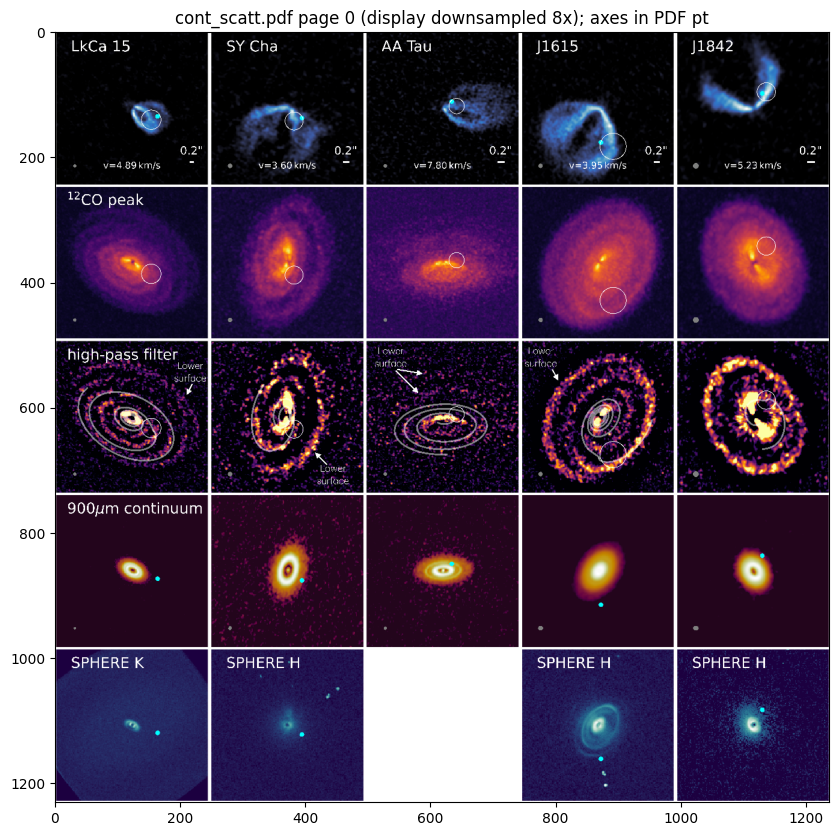

In [139]:
pix = page.get_pixmap(dpi=DPI)
pix.save('figure5_full_600dpi.png')
print('rendered size (px):', pix.width, pix.height)

full = np.frombuffer(pix.samples, np.uint8).reshape(pix.height, pix.width, pix.n)
plt.figure(figsize=(10, 10))
plt.imshow(full[::8, ::8], extent=(page.rect.x0, page.rect.x1, page.rect.y1, page.rect.y0))
plt.title('cont_scatt.pdf page 0 (display downsampled 8x); axes in PDF pt')
plt.show()

# used for all later crops: render a clip at 600 dpi, drawn with extent in PDF pt
def show(ax, r):
    p = page.get_pixmap(clip=r, dpi=DPI)
    s = 72 / DPI
    ax.imshow(np.frombuffer(p.samples, np.uint8).reshape(p.height, p.width, p.n),
              extent=(p.x * s, (p.x + p.width) * s, (p.y + p.height) * s, p.y * s))
    return p

## Cell 3: crop Figure 5

Panels are found from the vectors. Each matplotlib axes draws a white filled square (its facecolor) at exactly the axes rectangle, which also matches the clip path and the spines. The figure's bounding box is the union of those squares.

axes rectangles found: 24
Figure 5 bbox (pt): Rect(0.730987548828125, 0.14306640625, 1236.27294921875, 1229.28759765625)


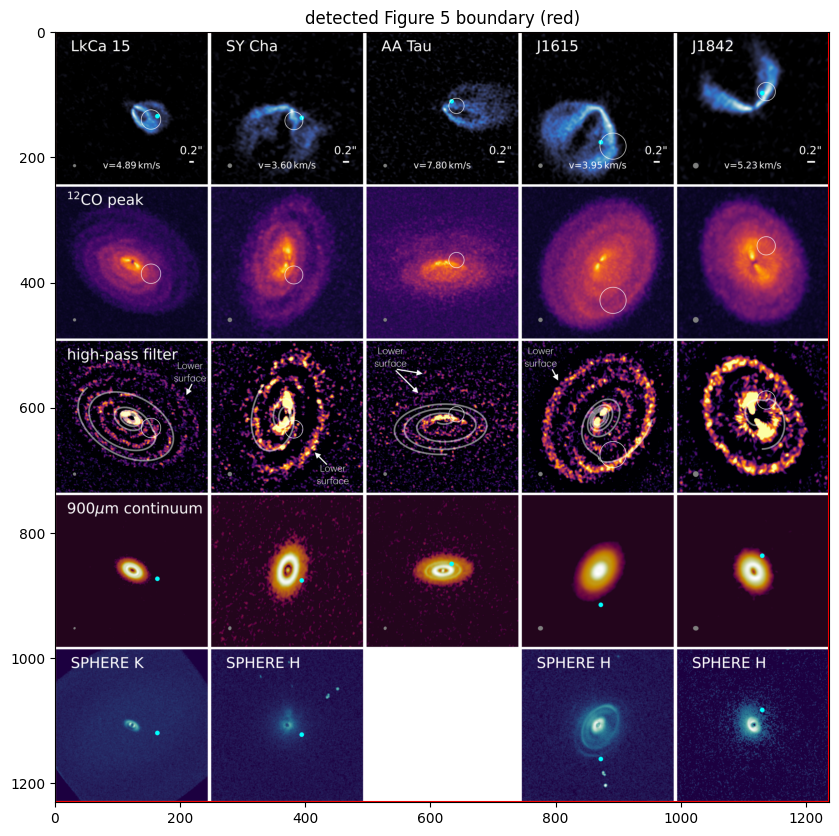

In [140]:
dr = page.get_drawings()
panels = [d['rect'] for d in dr if d['type'] == 'f' and d['fill'] == (1.0, 1.0, 1.0)
          and d['rect'].width > 200 and abs(d['rect'].width - d['rect'].height) < 0.01]
print('axes rectangles found:', len(panels))

fig_box = fitz.Rect(panels[0])
for r in panels:
    fig_box |= r
print('Figure 5 bbox (pt):', fig_box)

p = page.get_pixmap(clip=fig_box, dpi=DPI)
p.save('figure5_crop.png')

fig, ax = plt.subplots(figsize=(10, 10))
show(ax, fig_box + (-15, -15, 15, 15))
ax.add_patch(Rectangle((fig_box.x0, fig_box.y0), fig_box.width, fig_box.height, fill=False, ec='red', lw=1.5))
ax.set_title('detected Figure 5 boundary (red)')
plt.show()

## Cell 4: find the 5 columns

The panel labels are outlined glyphs, not text, so the disks cannot be read from the PDF text layer. The names below are assigned by column order, left to right. Check them against the labels in the crops.

distinct panel x0: [0.731, 248.647, 496.563, 744.479, 992.395]
distinct panel y0: [0.143, 246.46, 492.776, 739.093, 985.41]
LkCa15  column bounds (pt): x0=0.731 x1=244.609 y0=0.143 y1=1229.288  (5 panels)
SYCha   column bounds (pt): x0=248.647 x1=492.525 y0=0.143 y1=1229.288  (5 panels)
AATau   column bounds (pt): x0=496.563 x1=740.441 y0=0.143 y1=1229.288  (4 panels)
J1615   column bounds (pt): x0=744.479 x1=988.357 y0=0.143 y1=1229.288  (5 panels)
J1842   column bounds (pt): x0=992.395 x1=1236.273 y0=0.143 y1=1229.288  (5 panels)


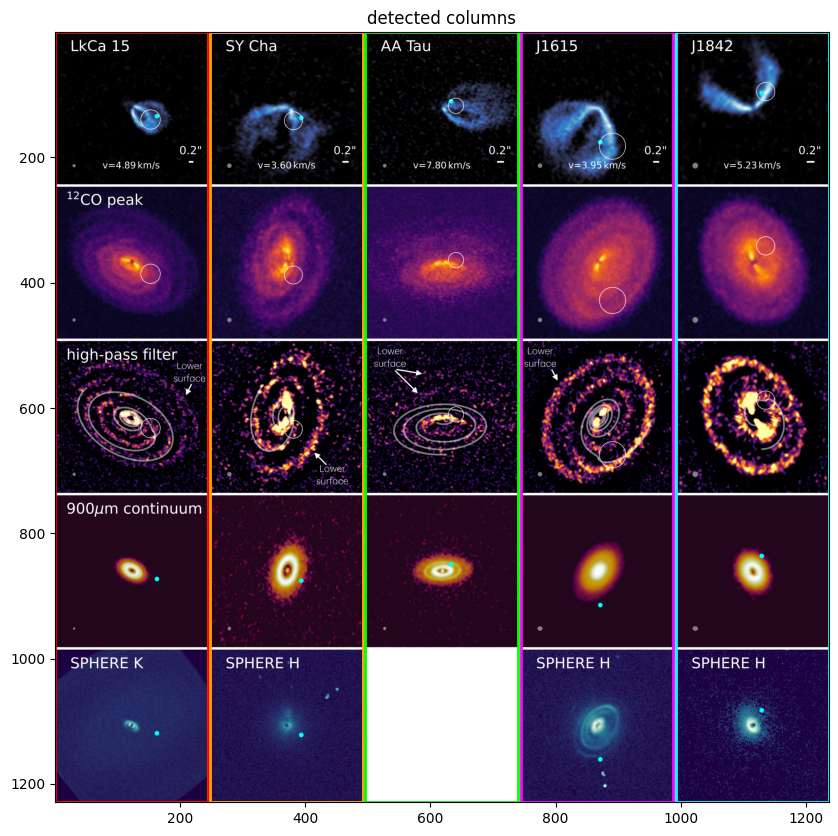

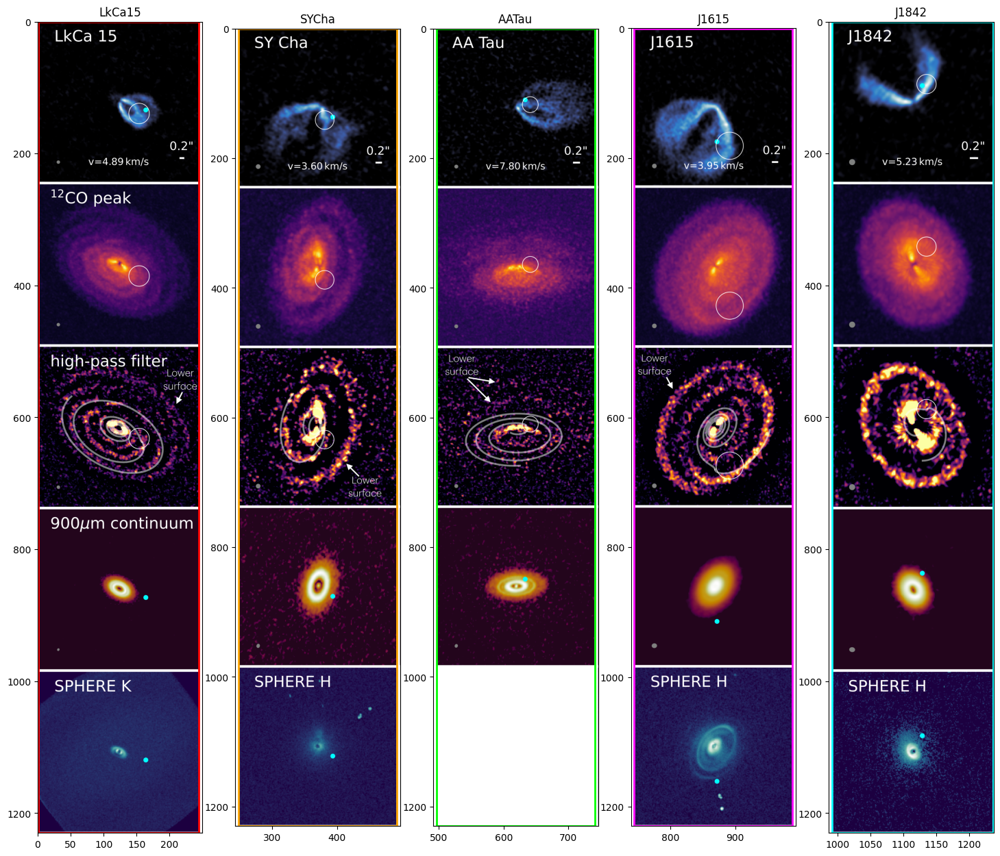

In [141]:
names = ['LkCa15', 'SYCha', 'AATau', 'J1615', 'J1842']
colors = ['red', 'orange', 'lime', 'magenta', 'cyan']
xs = sorted({round(r.x0, 3) for r in panels})
ys = sorted({round(r.y0, 3) for r in panels})
print('distinct panel x0:', xs)
print('distinct panel y0:', ys)

cols = {}
for n, x0 in zip(names, xs):
    c = [r for r in panels if round(r.x0, 3) == x0]
    cols[n] = fitz.Rect(min(r.x0 for r in c), fig_box.y0, max(r.x1 for r in c), fig_box.y1)
    print(f'{n:7s} column bounds (pt): x0={cols[n].x0:.3f} x1={cols[n].x1:.3f} y0={cols[n].y0:.3f} y1={cols[n].y1:.3f}  ({len(c)} panels)')

fig, ax = plt.subplots(figsize=(10, 10))
show(ax, fig_box)
for n, col in zip(names, colors):
    ax.add_patch(Rectangle((cols[n].x0, cols[n].y0), cols[n].width, cols[n].height, fill=False, ec=col, lw=2))
ax.set_title('detected columns')
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(18, 18))
for ax, n, col in zip(axs, names, colors):
    page.get_pixmap(clip=cols[n], dpi=DPI).save(f'crop_{n}_column.png')
    show(ax, cols[n] + (-5, -5, 5, 5))
    ax.add_patch(Rectangle((cols[n].x0, cols[n].y0), cols[n].width, cols[n].height, fill=False, ec=col, lw=2))
    ax.set_title(n)
plt.show()

**STOP: check that the five columns are the right disks in the right order.**

## Cell 5: crop row 1 (channel map) and row 4 (900 µm continuum)

LkCa15  row1 bbox (pt): Rect(0.730987548828125, 0.14306640625, 244.60888671875, 244.02099609375)
LkCa15  row4 bbox (pt): Rect(0.730987548828125, 739.093017578125, 244.60888671875, 982.9708862304688)
SYCha   row1 bbox (pt): Rect(248.6470947265625, 0.14306640625, 492.5250244140625, 244.02099609375)
SYCha   row4 bbox (pt): Rect(248.6470947265625, 739.093017578125, 492.5250244140625, 982.9708862304688)
AATau   row1 bbox (pt): Rect(496.56317138671875, 0.14306640625, 740.4410400390625, 244.02099609375)
AATau   row4 bbox (pt): Rect(496.56317138671875, 739.093017578125, 740.4410400390625, 982.9708862304688)
J1615   row1 bbox (pt): Rect(744.47900390625, 0.14306640625, 988.35693359375, 244.02099609375)
J1615   row4 bbox (pt): Rect(744.47900390625, 739.093017578125, 988.35693359375, 982.9708862304688)
J1842   row1 bbox (pt): Rect(992.39501953125, 0.14306640625, 1236.27294921875, 244.02099609375)
J1842   row4 bbox (pt): Rect(992.39501953125, 739.093017578125, 1236.27294921875, 982.9708862304688)


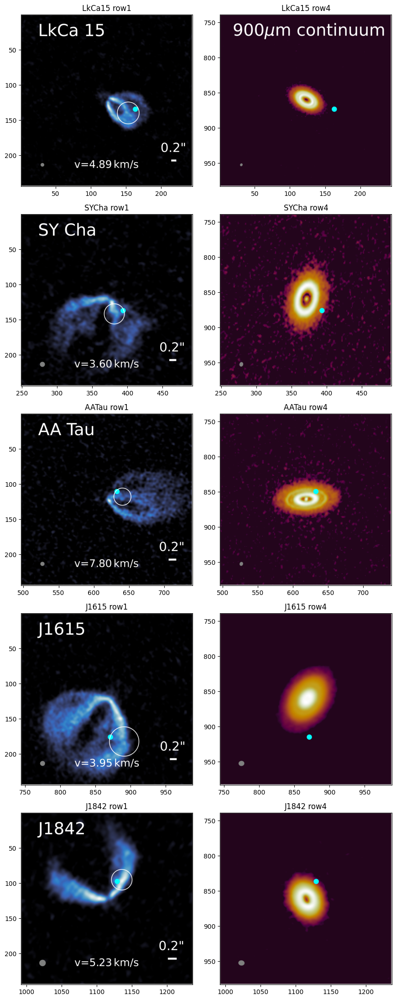

In [142]:
P = {}
for n, x0 in zip(names, xs):
    P[n] = {'row1': [r for r in panels if round(r.x0, 3) == x0 and round(r.y0, 3) == ys[0]][0],
            'row4': [r for r in panels if round(r.x0, 3) == x0 and round(r.y0, 3) == ys[3]][0]}
    for row in ['row1', 'row4']:
        page.get_pixmap(clip=P[n][row], dpi=DPI).save(f'{n}_{row}.png')
        print(f'{n:7s} {row} bbox (pt):', P[n][row])

fig, axs = plt.subplots(5, 2, figsize=(9, 22))
for i, n in enumerate(names):
    for j, row in enumerate(['row1', 'row4']):
        show(axs[i, j], P[n][row])
        axs[i, j].set_title(f'{n} {row}')
plt.tight_layout()
plt.show()

## Cell 6: panel geometry

In [143]:
geo = []
for n in names:
    r1, r4 = P[n]['row1'], P[n]['row4']
    print(f'{n}: row1 L={r1.x0:.4f} R={r1.x1:.4f} T={r1.y0:.4f} B={r1.y1:.4f} W={r1.width:.4f} H={r1.height:.4f}')
    print(f'{" " * len(n)}  row4 L={r4.x0:.4f} R={r4.x1:.4f} T={r4.y0:.4f} B={r4.y1:.4f} W={r4.width:.4f} H={r4.height:.4f}')
    geo.append(dict(disk=n, row1_width=r1.width, row4_width=r4.width, width_ratio=r4.width / r1.width,
                    row1_height=r1.height, row4_height=r4.height, height_ratio=r4.height / r1.height))
geo = pd.DataFrame(geo)
print()
print(geo.to_string(index=False, float_format='%.5f'))

LkCa15: row1 L=0.7310 R=244.6089 T=0.1431 B=244.0210 W=243.8779 H=243.8779
        row4 L=0.7310 R=244.6089 T=739.0930 B=982.9709 W=243.8779 H=243.8779
SYCha: row1 L=248.6471 R=492.5250 T=0.1431 B=244.0210 W=243.8779 H=243.8779
       row4 L=248.6471 R=492.5250 T=739.0930 B=982.9709 W=243.8779 H=243.8779
AATau: row1 L=496.5632 R=740.4410 T=0.1431 B=244.0210 W=243.8779 H=243.8779
       row4 L=496.5632 R=740.4410 T=739.0930 B=982.9709 W=243.8779 H=243.8779
J1615: row1 L=744.4790 R=988.3569 T=0.1431 B=244.0210 W=243.8779 H=243.8779
       row4 L=744.4790 R=988.3569 T=739.0930 B=982.9709 W=243.8779 H=243.8779
J1842: row1 L=992.3950 R=1236.2729 T=0.1431 B=244.0210 W=243.8779 H=243.8779
       row4 L=992.3950 R=1236.2729 T=739.0930 B=982.9709 W=243.8779 H=243.8779

  disk  row1_width  row4_width  width_ratio  row1_height  row4_height  height_ratio
LkCa15   243.87790   243.87790      1.00000    243.87793    243.87787       1.00000
 SYCha   243.87793   243.87793      1.00000    243.87793    2

## Cell 7: find the 0.2" scale bar in row 1 (vector)

A candidate is a stroked path that is a single straight segment, horizontal, white, lies inside the row-1 panel, and is shorter than the panel (which excludes the spines). There must be exactly one candidate per panel.

The zoomed diagnostic shows:
- the bar path in red, with its endpoints as yellow dots;
- the bounding box of the white label glyphs above the bar (dashed yellow; "0.2"" is drawn as outlined glyphs);
- every other stroked path in the window, dashed cyan.

`L_bar` is the path length between the endpoints. The printed line cap shows whether the drawn stroke is longer than the path.

LkCa15: 1 horizontal white stroke candidate(s)
SYCha: 1 horizontal white stroke candidate(s)
AATau: 1 horizontal white stroke candidate(s)
J1615: 1 horizontal white stroke candidate(s)
J1842: 1 horizontal white stroke candidate(s)


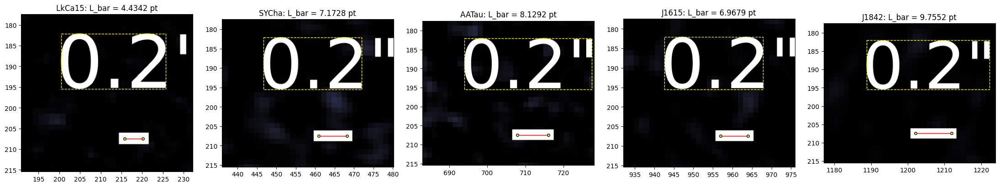

        scale_x1  scale_y1  scale_x2  scale_y2  L_bar_native  linewidth  lineCap
LkCa15  215.7870  207.4390  220.2212  207.4390        4.4342     2.7713   2.0000
SYCha   460.9645  207.4390  468.1373  207.4390        7.1728     2.7713   2.0000
AATau   707.9242  207.4390  716.0534  207.4390        8.1292     2.7713   2.0000
J1615   957.0017  207.4390  963.9696  207.4390        6.9679     2.7713   2.0000
J1842  1202.1307  207.4390 1211.8860  207.4390        9.7552     2.7713   2.0000

lineCap 2 = projecting square: the drawn bar is L_bar + linewidth long. The path length L_bar is the calibration, not the visible length.


In [144]:
white = lambda c: c is not None and min(c) > 0.99
SB = {}
fig, axs = plt.subplots(1, 5, figsize=(22, 5))
for ax, n in zip(axs, names):
    r = P[n]['row1']
    cand = []
    for d in dr:
        if d['type'] == 's' and white(d['color']) and len(d['items']) == 1 and d['items'][0][0] == 'l':
            a, b = d['items'][0][1], d['items'][0][2]
            if a.y == b.y and r.contains(a) and r.contains(b) and abs(b.x - a.x) < 0.5 * r.width:
                cand.append(d)
    print(f'{n}: {len(cand)} horizontal white stroke candidate(s)')
    assert len(cand) == 1, f'AMBIGUOUS scale bar for {n}'
    d = cand[0]
    a, b = sorted([d['items'][0][1], d['items'][0][2]], key=lambda q: q.x)
    SB[n] = dict(scale_x1=a.x, scale_y1=a.y, scale_x2=b.x, scale_y2=b.y, L_bar_native=abs(b - a),
                 linewidth=d['width'], lineCap=d['lineCap'][0])

    win = fitz.Rect(a.x - 25, a.y - 30, b.x + 12, a.y + 8) & r
    show(ax, win)
    glyphs = [g['rect'] for g in dr if g['type'] == 'f' and white(g['fill']) and win.contains(g['rect'])
              and g['rect'].y1 < a.y and g['rect'].width < 20]
    if glyphs:
        gb = fitz.Rect(glyphs[0])
        for g in glyphs:
            gb |= g
        ax.add_patch(Rectangle((gb.x0, gb.y0), gb.width, gb.height, fill=False, ec='yellow', ls='--', lw=1))
    for o in dr:
        if o['type'] == 's' and o is not d and o['rect'].intersects(win):
            ax.add_patch(Rectangle((o['rect'].x0, o['rect'].y0), o['rect'].width, o['rect'].height, fill=False, ec='cyan', ls='--', lw=1))
    ax.plot([a.x, b.x], [a.y, b.y], 'r-', lw=1)
    ax.plot([a.x, b.x], [a.y, b.y], 'o', ms=4, mfc='yellow', mec='k')
    ax.set_xlim(win.x0, win.x1); ax.set_ylim(win.y1, win.y0)
    ax.set_title(f'{n}: L_bar = {SB[n]["L_bar_native"]:.4f} pt')
plt.tight_layout()
fig.savefig('diag_scalebar_row1.png', dpi=200)
plt.show()

sb = pd.DataFrame(SB).T.astype(float)
print(sb.to_string(float_format='%.4f'))
print('\nlineCap 2 = projecting square: the drawn bar is L_bar + linewidth long. The path length L_bar is the calibration, not the visible length.')

**STOP: check the scale-bar detections.**

## Cell 8: geometric centre of each row-4 panel

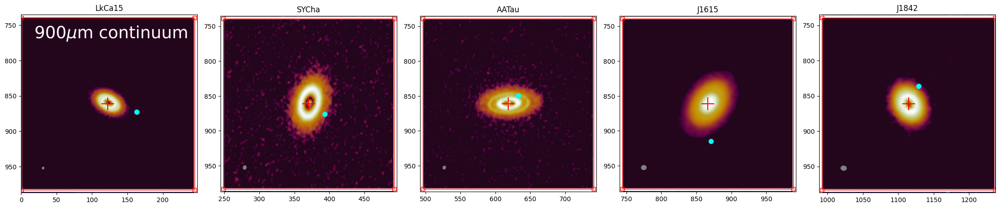

             x_c      y_c
LkCa15  122.6699 861.0320
SYCha   370.5861 861.0320
AATau   618.5021 861.0320
J1615   866.4180 861.0320
J1842  1114.3340 861.0320


In [145]:
C = {}
fig, axs = plt.subplots(1, 5, figsize=(22, 5))
for ax, n in zip(axs, names):
    r = P[n]['row4']
    C[n] = dict(x_c=(r.x0 + r.x1) / 2, y_c=(r.y0 + r.y1) / 2)
    show(ax, r + (-4, -4, 4, 4))
    ax.add_patch(Rectangle((r.x0, r.y0), r.width, r.height, fill=False, ec='red', lw=1))
    ax.plot([r.x0, r.x1, r.x0, r.x1], [r.y0, r.y0, r.y1, r.y1], 's', ms=6, mfc='none', mec='red')
    ax.plot(C[n]['x_c'], C[n]['y_c'], 'r+', ms=20, mew=1.5)
    ax.set_title(n)
plt.tight_layout()
fig.savefig('diag_row4_centre.png', dpi=200)
plt.show()
print(pd.DataFrame(C).T.to_string(float_format='%.4f'))

## Cell 9: find the cyan dot in row 4 (vector)

A candidate is a filled path with fill colour (0, 1, 1) whose centre lies inside the row-4 panel. There must be exactly one. Its centre is the centre of the circle path's bounding box.

LkCa15: 1 cyan filled path(s) in row 4 (vector), diameter = [5.543] pt
SYCha: 1 cyan filled path(s) in row 4 (vector), diameter = [5.543] pt
AATau: 1 cyan filled path(s) in row 4 (vector), diameter = [5.543] pt
J1615: 1 cyan filled path(s) in row 4 (vector), diameter = [5.543] pt
J1842: 1 cyan filled path(s) in row 4 (vector), diameter = [5.543] pt


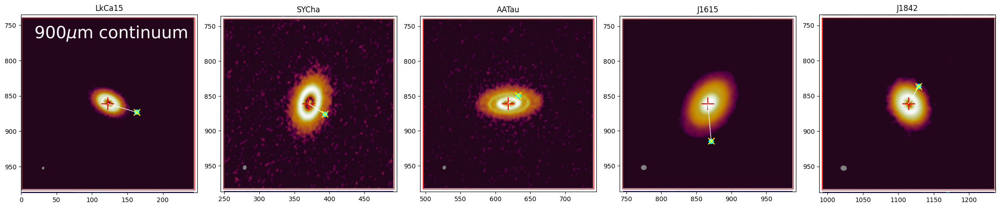

             x_p      y_p  dx_native  dy_native
LkCa15  163.4641 873.4475    40.7942    12.4155
SYCha   393.8981 876.0948    23.3120    15.0629
AATau   633.1349 849.6509    14.6328   -11.3810
J1615   871.2959 915.0334     4.8780    54.0015
J1842  1128.9674 836.6441    14.6334   -24.3879


In [146]:
D = {}
fig, axs = plt.subplots(1, 5, figsize=(22, 5))
for ax, n in zip(axs, names):
    r = P[n]['row4']
    cand = [d for d in dr if d['fill'] is not None and np.allclose(d['fill'], (0, 1, 1), atol=0.01)
            and r.contains((d['rect'].tl + d['rect'].br) / 2)]
    print(f'{n}: {len(cand)} cyan filled path(s) in row 4 (vector), diameter = {[round(c["rect"].width, 3) for c in cand]} pt')
    assert len(cand) == 1, f'AMBIGUOUS dot for {n}'
    q = cand[0]['rect']
    D[n] = dict(x_p=(q.x0 + q.x1) / 2, y_p=(q.y0 + q.y1) / 2)
    D[n].update(dx_native=D[n]['x_p'] - C[n]['x_c'], dy_native=D[n]['y_p'] - C[n]['y_c'])

    show(ax, r + (-4, -4, 4, 4))
    ax.add_patch(Rectangle((r.x0, r.y0), r.width, r.height, fill=False, ec='red', lw=1))
    ax.plot(C[n]['x_c'], C[n]['y_c'], 'r+', ms=20, mew=1.5)
    ax.plot([C[n]['x_c'], D[n]['x_p']], [C[n]['y_c'], D[n]['y_p']], 'w-', lw=1)
    ax.plot(D[n]['x_p'], D[n]['y_p'], 'x', color='yellow', ms=10, mew=1.5)
    ax.set_title(n)
plt.tight_layout()
fig.savefig('diag_row4_dot.png', dpi=200)
plt.show()
print(pd.DataFrame(D).T.to_string(float_format='%.4f'))

**STOP: check the dot detections.**

## Cell 10: convert native offsets to arcsec (image plane)

Row 1 and row 4 are assumed to show the same angular field. If their panel sizes differed, the scale would be multiplied by `row1_width / row4_width`.

In [147]:
res = []
for n in names:
    g = geo[geo.disk == n].iloc[0]
    s = 0.2 / SB[n]['L_bar_native'] * g.row1_width / g.row4_width
    res.append(dict(disk=n, row1_width=g.row1_width, row4_width=g.row4_width, L_bar_native=SB[n]['L_bar_native'],
                    scale_arcsec_per_native=s, **C[n], **D[n],
                    x_image_arcsec=D[n]['dx_native'] * s, y_image_arcsec=-D[n]['dy_native'] * s))
res = pd.DataFrame(res)
print(res.to_string(index=False, float_format='%.5f'))

  disk  row1_width  row4_width  L_bar_native  scale_arcsec_per_native        x_c       y_c        x_p       y_p  dx_native  dy_native  x_image_arcsec  y_image_arcsec
LkCa15   243.87790   243.87790       4.43416                  0.04510  122.66994 861.03195  163.46410 873.44748   40.79417   12.41553         1.84000        -0.55999
 SYCha   243.87793   243.87793       7.17279                  0.02788  370.58606 861.03195  393.89809 876.09485   23.31203   15.06290         0.65001        -0.42000
 AATau   243.87787   243.87787       8.12921                  0.02460  618.50211 861.03195  633.13492 849.65091   14.63281  -11.38104         0.36001         0.28000
 J1615   243.87793   243.87793       6.96790                  0.02870  866.41797 861.03195  871.29593 915.03345    4.87796   54.00150         0.14001        -1.55001
 J1842   243.87793   243.87793       9.75525                  0.02050 1114.33398 861.03195 1128.96741 836.64407   14.63342  -24.38788         0.30001         0.49999


## Cell 11: save the raw result (the file is never overwritten)

In [148]:
import os
fn, i = 'figure5_blue_dot_raw.txt', 1
while os.path.exists(fn):   # never overwrite an earlier result: use the next free _vN name
    i += 1
    fn = f'figure5_blue_dot_raw_v{i}.txt'
with open(fn, 'x') as f:
    f.write(res.rename(columns={'disk': 'disk_name'})[['disk_name', 'x_image_arcsec', 'y_image_arcsec',
            'scale_arcsec_per_native', 'dx_native', 'dy_native']].to_string(index=False, float_format='%.6f') + '\n')
print(fn)
print(open(fn).read())

figure5_blue_dot_raw_v9.txt
disk_name  x_image_arcsec  y_image_arcsec  scale_arcsec_per_native  dx_native  dy_native
   LkCa15        1.839996       -0.559995                 0.045104  40.794167  12.415527
    SYCha        0.650013       -0.420001                 0.027883  23.312027  15.062897
    AATau        0.360006        0.280004                 0.024603  14.632812 -11.381042
    J1615        0.140012       -1.550009                 0.028703   4.877960  54.001495
    J1842        0.300011        0.499995                 0.020502  14.633423 -24.387878



## Cell 12: alternative calibration from the visible (rendered) bar length

The bar is rasterised at 2400 dpi. Along the bar's centre row, each outer edge is where the brightness crosses halfway between the local background and the white bar, interpolated to sub-pixel precision.

- `arcsec_per_native = 0.2 / visible_bar_length`
- `panel_width_arcsec = row-4 panel width × arcsec_per_native`
- The normalised dot position (xf, yf) from Cell 9 is converted with this panel width. (0, 0) is the lower-left corner, and x and y are image-plane offsets from the panel centre (x to the right, y up).

The vector path length (Cell 7) is not used here.

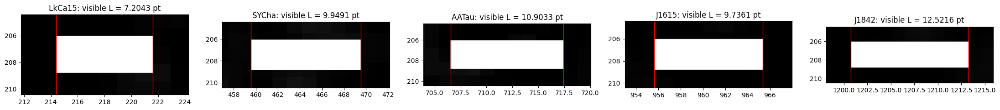

  disk     x_left    x_right  visible_bar_length  arcsec_per_native  panel_width_native  panel_width_arcsec      xf      yf  x_image_arcsec  y_image_arcsec
LkCa15  214.40387  221.60818             7.20431            0.02776           243.87790             6.77033 0.66727 0.44909         1.13249        -0.34467
 SYCha  459.57631  469.52537             9.94906            0.02010           243.87793             4.90253 0.59559 0.43824         0.46863        -0.30280
 AATau  706.53523  717.43850            10.90327            0.01834           243.87787             4.47348 0.56000 0.54667         0.26841         0.20876
 J1615  955.61694  965.35301             9.73607            0.02054           243.87793             5.00978 0.52000 0.27857         0.10020        -1.10931
 J1842 1200.74687 1213.26847            12.52159            0.01597           243.87793             3.89532 0.56000 0.60000         0.23373         0.38953


In [149]:
BAR_DPI = 2400
k = 72 / BAR_DPI
V = []
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
for ax, n in zip(axs, names):
    s = SB[n]
    win = fitz.Rect(s['scale_x1'] - 4, s['scale_y1'] - 3, s['scale_x2'] + 4, s['scale_y1'] + 3)
    p = page.get_pixmap(clip=win, dpi=BAR_DPI)
    a = np.frombuffer(p.samples, np.uint8).reshape(p.height, p.width, p.n).min(axis=2).astype(float)
    x = (p.x + np.arange(p.width) + 0.5) * k    # pixel-centre coordinates in pt
    y = (p.y + np.arange(p.height) + 0.5) * k
    prof = a[np.argmin(abs(y - s['scale_y1']))]
    half = (np.median(prof[:60]) + prof.max()) / 2
    i = np.where(prof > half)[0]
    i0, i1 = i[0], i[-1]
    x_left = np.interp(half, [prof[i0 - 1], prof[i0]], [x[i0 - 1], x[i0]])
    x_right = np.interp(half, [prof[i1 + 1], prof[i1]], [x[i1 + 1], x[i1]])

    L_vis = x_right - x_left
    scale_vis = 0.2 / L_vis
    r = P[n]['row4']
    W_vis = r.width * scale_vis
    xf, yf = (D[n]['x_p'] - r.x0) / r.width, (r.y1 - D[n]['y_p']) / r.height
    V.append(dict(disk=n, x_left=x_left, x_right=x_right, visible_bar_length=L_vis, arcsec_per_native=scale_vis,
                  panel_width_native=r.width, panel_width_arcsec=W_vis, xf=xf, yf=yf,
                  x_image_arcsec=(xf - 0.5) * W_vis, y_image_arcsec=(yf - 0.5) * W_vis))

    ax.imshow(a, cmap='gray', extent=(x[0] - k / 2, x[-1] + k / 2, y[-1] + k / 2, y[0] - k / 2))
    ax.axvline(x_left, color='red', lw=1)
    ax.axvline(x_right, color='red', lw=1)
    ax.set_title(f'{n}: visible L = {L_vis:.4f} pt')
plt.tight_layout()
fig.savefig('diag_scalebar_visible.png', dpi=200)
plt.show()

vis = pd.DataFrame(V)
print(vis.to_string(index=False, float_format='%.5f'))

# Alternative: kink.ipynb approach

Cells copied from `kink.ipynb` (panel width W + point fraction of panel), to compare with the vector measurement above.

panel_width: {'LkCa_15': 6.770334914888522, 'SY_Cha': 4.902532252886026, 'AA_Tau': 4.47348302866543, 'J1615': 5.009780951910284, 'J1842': 3.895317567514844}
points: {'LkCa_15': (0.6672729128133013, 0.44909120941413194), 'SY_Cha': (0.595588916173803, 0.43823590138886975), 'AA_Tau': (0.5600005756195104, 0.5466669753322013), 'J1615': (0.5200016467719266, 0.27857156264429594), 'J1842': (0.5600030632961066, 0.6000003754040286)}
disk_name   x_point   y_point  x_centre  y_centre  X_sky_arcsec  Y_sky_arcsec
  LkCa_15 -1.149338 -0.323841 -0.016844  0.020828     -1.132494     -0.344670
   SY_Cha -0.481283 -0.274642 -0.012655  0.028159     -0.468628     -0.302800
   AA_Tau -0.273871  0.213591 -0.005459  0.004827     -0.268412      0.208764
    J1615 -0.144521 -1.115192 -0.044317 -0.005884     -0.100204     -1.109308
    J1842 -0.236896  0.358844 -0.003165 -0.030689     -0.233731      0.389533


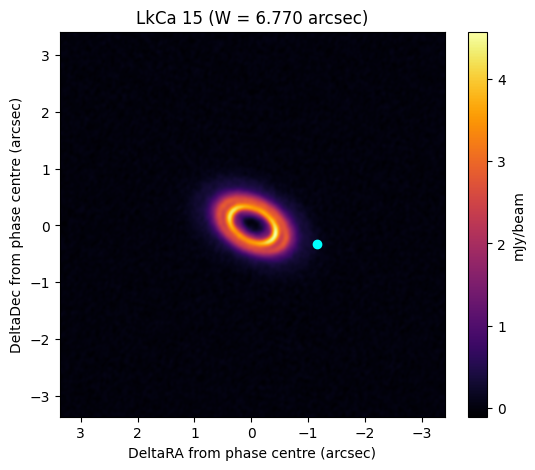

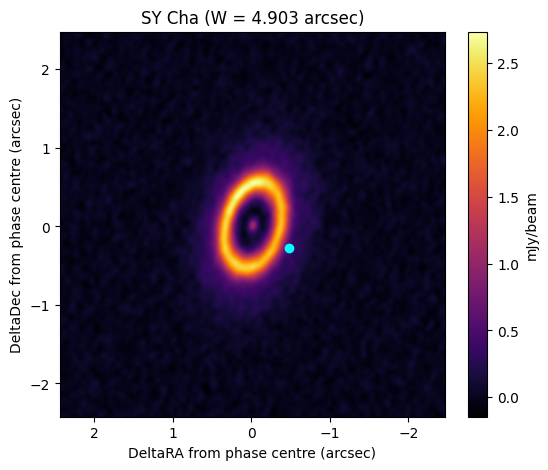

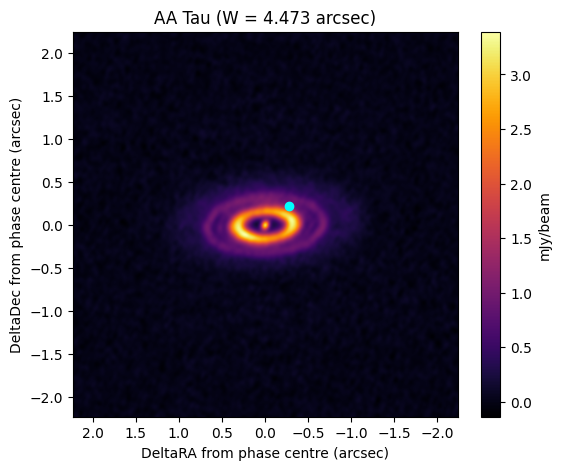

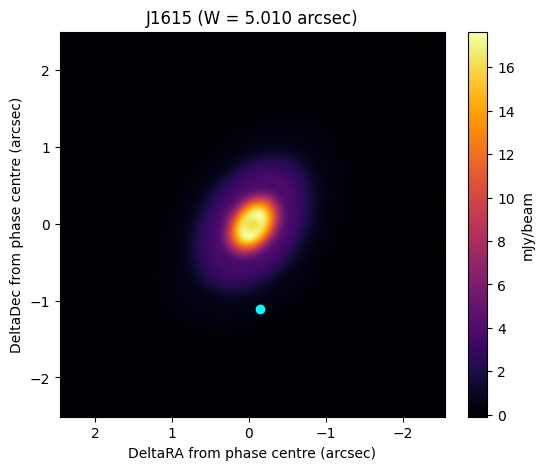

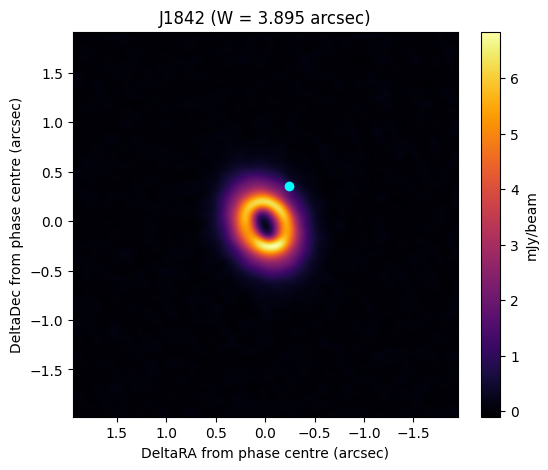

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

base = r"D:\exoALMA_disk_data"

# panel width W (arcsec) and dot position as a fraction (0-1) of the panel, from Cell 12 (visible bar length calibration):
# W = row-4 panel width * 0.2 / visible_bar_length, fraction from the vector dot centre inside the row-4 panel.
# (0,0) = lower-left, (1,1) = upper-right, panel centred on the disk centre
# (to go back to the vector path-length calibration: W = m.row4_width * m.scale_arcsec_per_native, looping over res)
kname = {"LkCa15": "LkCa_15", "SYCha": "SY_Cha", "AATau": "AA_Tau", "J1615": "J1615", "J1842": "J1842"}
kinv = {v: k for k, v in kname.items()}
panel_width, points = {}, {}
for _, m in vis.iterrows():
    panel_width[kname[m.disk]] = m.panel_width_arcsec
    points[kname[m.disk]] = (m.xf, m.yf)
print("panel_width:", panel_width)
print("points:", points)

# every x/y below is a FITS offset from the phase centre (CRPIX), in arcsec:
#   x = DeltaRA  (positive = east = LEFT on the image)
#   y = DeltaDec (positive = north = up)
# disk centre in these coords = (dx, dy) from diskdictionary_eqC1
rows = []
for name, W in panel_width.items():
    d = diskdict.disk[name]
    xf, yf = points[name]
    x_centre, y_centre = d["dx"], d["dy"]
    x_point = x_centre + W / 2 - xf * W   # panel fraction increases to the right (west), DeltaRA increases to the east
    y_point = y_centre + yf * W - W / 2
    rows.append(dict(disk_name=name, x_point=x_point, y_point=y_point, x_centre=x_centre, y_centre=y_centre,
                     X_sky_arcsec=x_point - x_centre, Y_sky_arcsec=y_point - y_centre))

print(pd.DataFrame(rows).to_string(index=False))

for row in rows:
    name, W = row["disk_name"], panel_width[row["disk_name"]]
    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust0.5.image.fits")
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    RAo  = 3600 * hd["CDELT1"] * (np.arange(hd["NAXIS1"]) - (hd["CRPIX1"] - 1))
    DECo = 3600 * hd["CDELT2"] * (np.arange(hd["NAXIS2"]) - (hd["CRPIX2"] - 1))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(img, origin="lower", cmap="inferno", extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
    fig.colorbar(im, ax=ax, fraction=0.046, label="mJy/beam")
    ax.plot(row["x_point"], row["y_point"], "o", color="cyan", markersize=6)
    ax.set_title(f"{name.replace('_', ' ')} (W = {W:.3f} arcsec)")
    ax.set_xlabel("DeltaRA from phase centre (arcsec)")
    ax.set_ylabel("DeltaDec from phase centre (arcsec)")
    ax.set_xlim(row["x_centre"] + W / 2, row["x_centre"] - W / 2)
    ax.set_ylim(row["y_centre"] - W / 2, row["y_centre"] + W / 2)
    plt.show()


In [151]:
geo = pd.DataFrame(rows)
geo["PA_deg"] = [diskdict.disk[n]["PA"] for n in geo.disk_name]
geo["inclination_deg"] = [diskdict.disk[n]["incl"] for n in geo.disk_name]
PA, inc = np.radians(geo.PA_deg), np.radians(geo.inclination_deg)
X, Y = geo.X_sky_arcsec, geo.Y_sky_arcsec

geo["x_maj_arcsec"] = X * np.sin(PA) + Y * np.cos(PA)
geo["y_min_arcsec"] = -X * np.cos(PA) + Y * np.sin(PA)
geo["x_disk_arcsec"] = geo.x_maj_arcsec
geo["y_disk_arcsec"] = geo.y_min_arcsec / np.cos(inc)
geo["r_arcsec"] = np.hypot(geo.x_disk_arcsec, geo.y_disk_arcsec)
geo["distance_pc"] = [diskdict.disk[n]["distance"] for n in geo.disk_name]
geo["r_AU"] = geo.r_arcsec * geo.distance_pc
# theta = 0: along the major axis in the direction of PA (east of north).
# theta increases from there toward the +y_min axis, i.e. toward PA - 90 deg
# (clockwise on the sky as displayed, east left / north up). Range (-180, 180] from arctan2, no wrapping.
geo["theta_deg"] = np.degrees(np.arctan2(geo.y_disk_arcsec, geo.x_disk_arcsec))

print(geo.to_string(index=False))
geo.to_csv("disk_plane_coordinates.txt", sep="\t", index=False)

disk_name   x_point   y_point  x_centre  y_centre  X_sky_arcsec  Y_sky_arcsec     PA_deg  inclination_deg  x_maj_arcsec  y_min_arcsec  x_disk_arcsec  y_disk_arcsec  r_arcsec  distance_pc       r_AU  theta_deg
  LkCa_15 -1.149338 -0.323841 -0.016844  0.020828     -1.132494     -0.344670  61.572325        50.594940     -1.160016      0.236014      -1.160016       0.371793  1.218141          156 190.029928 162.228996
   SY_Cha -0.481283 -0.274642 -0.012655  0.028159     -0.468628     -0.302800 165.765113        51.646422      0.178269     -0.528697       0.178269      -0.852032  0.870482          182 158.427723 -78.182607
   AA_Tau -0.273871  0.213591 -0.005459  0.004827     -0.268412      0.208764  93.770798        58.535312     -0.281560      0.190660      -0.281560       0.365268  0.461190          135  62.260673 127.626184
    J1615 -0.144521 -1.115192 -0.044317 -0.005884     -0.100204     -1.109308 146.143279        47.097757      0.865381     -0.701228       0.865381      -1.030082 

In [152]:
# Table 2 of the phantom + mcfost paper: r_planet (au)
r_planet_paper = {"AA_Tau": 80, "J1615": 310, "J1842": 105, "LkCa_15": 240, "SY_Cha": 140}

cmp = geo[["disk_name", "r_AU", "theta_deg"]].copy()
cmp["r_planet_paper_AU"] = [r_planet_paper[n] for n in cmp.disk_name]
cmp["r_AU / r_planet"] = cmp.r_AU / cmp.r_planet_paper_AU
print(cmp.to_string(index=False))

disk_name       r_AU  theta_deg  r_planet_paper_AU  r_AU / r_planet
  LkCa_15 190.029928 162.228996                240         0.791791
   SY_Cha 158.427723 -78.182607                140         1.131627
   AA_Tau  62.260673 127.626184                 80         0.778258
    J1615 209.873853 -49.966094                310         0.677012
    J1842  83.219092  63.568674                105         0.792563


In [153]:
cmp["W_current_arcsec"] = [panel_width[n] for n in cmp.disk_name]
cmp["W_required_arcsec"] = cmp.W_current_arcsec * cmp.r_planet_paper_AU / cmp.r_AU
print(cmp[["disk_name", "W_current_arcsec", "r_AU", "r_planet_paper_AU", "W_required_arcsec"]].to_string(index=False))

disk_name  W_current_arcsec       r_AU  r_planet_paper_AU  W_required_arcsec
  LkCa_15          6.770335 190.029928                240           8.550655
   SY_Cha          4.902532 158.427723                140           4.332288
   AA_Tau          4.473483  62.260673                 80           5.748069
    J1615          5.009781 209.873853                310           7.399836
    J1842          3.895318  83.219092                105           4.914838


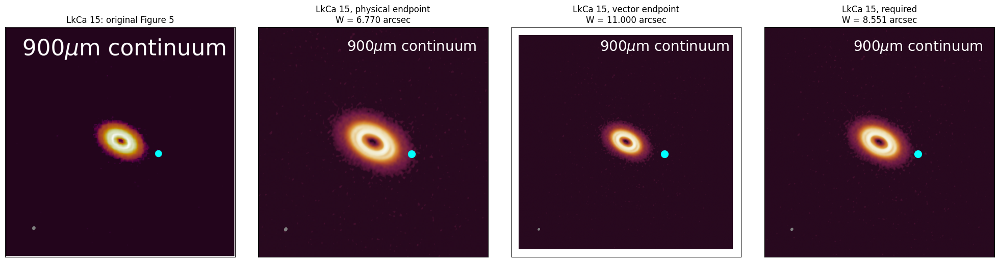

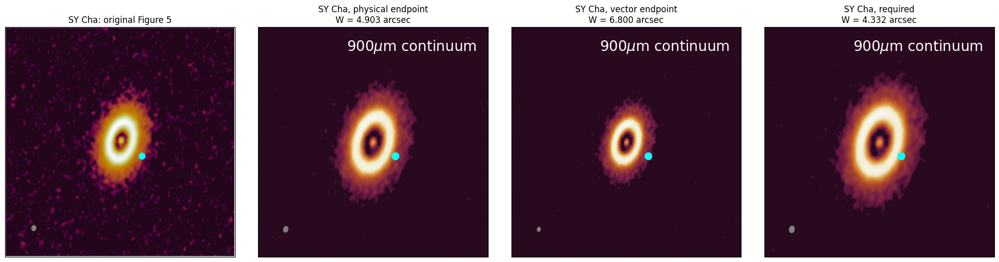

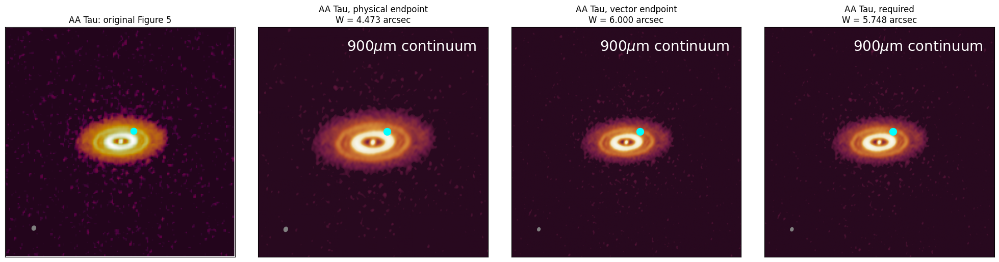

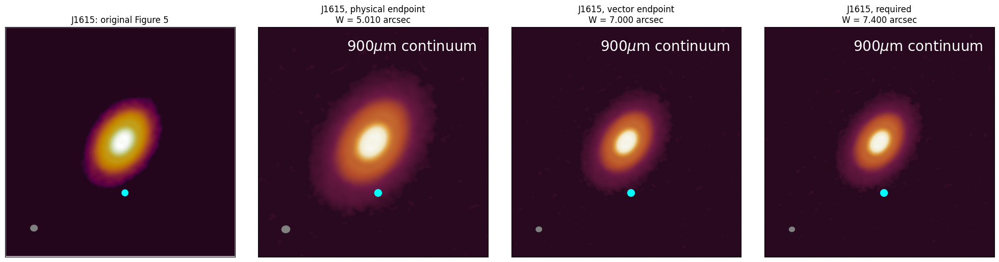

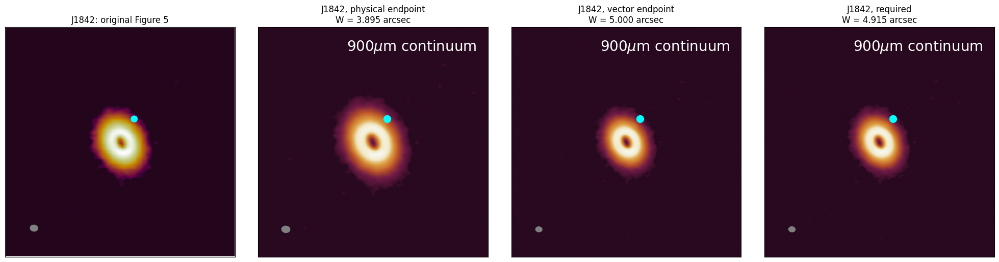

In [154]:
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# every disk in the paper's panel style: original Figure 5 row-4 panel | FITS at W from the physical (visible) bar ends |
# FITS at W from the vector path endpoints | FITS at required W.
# the point sits at the same panel fraction (xf, yf) in all FITS panels, so its arcsec position scales with W
# paper-like colours: maroon background -> magenta rim -> orange -> cream ring; sqrt stretch, noise below 3 sigma clipped
cmap = LinearSegmentedColormap.from_list("paper", ["#28091f", "#6e1a45", "#b8502a", "#dc9a3c", "#f0e6c0", "#f7f7ee"])

for name in panel_width:
    d = diskdict.disk[name]
    xf, yf = points[name]
    hdu = fits.open(f"{base}/{name}/images_data_different_robust/{name}_continuum_data_robust0.5.image.fits")  # robust 0.5 = the image used in Figure 5 (beam matches)
    img = 1e3 * np.squeeze(hdu[0].data)   # mJy/beam
    hd = hdu[0].header
    RAo  = 3600 * hd["CDELT1"] * (np.arange(hd["NAXIS1"]) - (hd["CRPIX1"] - 1)) - d["dx"]
    DECo = 3600 * hd["CDELT2"] * (np.arange(hd["NAXIS2"]) - (hd["CRPIX2"] - 1)) - d["dy"]
    bmaj, bmin, bpa = 3600 * hd["BMAJ"], 3600 * hd["BMIN"], hd["BPA"]
    rms = np.std(img[:200, :200])
    norm = PowerNorm(0.5, vmin=3 * rms, vmax=img.max(), clip=True)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    p = page.get_pixmap(clip=P[kinv[name]]["row4"], dpi=DPI)
    axs[0].imshow(np.frombuffer(p.samples, np.uint8).reshape(p.height, p.width, p.n))
    axs[0].set_title(f"{name.replace('_', ' ')}: original Figure 5")

    m = res[res.disk == kinv[name]].iloc[0]
    Ws = [panel_width[name], m.row4_width * m.scale_arcsec_per_native, cmp.W_required_arcsec[cmp.disk_name == name].item()]
    for ax, W, label in zip(axs[1:], Ws, ["physical endpoint", "vector endpoint", "required"]):
        ax.imshow(img, origin="lower", cmap=cmap, norm=norm, extent=[RAo[0], RAo[-1], DECo[0], DECo[-1]])
        ax.plot(W * (0.5 - xf), W * (yf - 0.5), "o", color="cyan", markersize=10)
        ax.add_patch(Ellipse((0.38 * W, -0.38 * W), bmin, bmaj, angle=-bpa, color="grey"))
        ax.text(0.95, 0.95, "900$\\mu$m continuum", color="white", fontsize=20, ha="right", va="top", transform=ax.transAxes)
        ax.set_xlim(W / 2, -W / 2)
        ax.set_ylim(-W / 2, W / 2)
        ax.set_title(f"{name.replace('_', ' ')}, {label}\nW = {W:.3f} arcsec")
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()


## Note: θ does not depend on the scale-bar calibration

The kink cells give the sky offset as

- `X_sky = W·(0.5 − xf)`
- `Y_sky = W·(yf − 0.5)`

Here (xf, yf) is the dot's position as a fraction of the panel. It is the same whichever calibration is used; only the panel width W changes. Switching calibration therefore scales both offsets by the same factor k = W_physical / W_vector:

| disk | k |
|---|---|
| LkCa 15 | 0.615 |
| SY Cha | 0.721 |
| AA Tau | 0.746 |
| J1615 | 0.716 |
| J1842 | 0.779 |

The deprojection is linear in (X, Y): a rotation by PA, then dividing the minor-axis part by cos i. So x_disk and y_disk also both scale by k. Then

- θ = arctan2(y_disk, x_disk) is **unchanged**, because arctan2(k·a, k·b) = arctan2(a, b) for any k > 0;
- only r changes, and it scales by the same k.

θ would only change if the scale differed between x and y, or if the reference point were not the panel centre. Neither happens here: the panels are square, one scale bar sets both axes, and the centre is the geometric panel centre. θ therefore depends only on (xf, yf) and on PA and inclination.